In [4]:
# Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
plt.style.use('seaborn-v0_8')
sns.set_palette('Set2')


## STEP 1: LOAD AND EXPLORE DATA

In [5]:
column_names = [
    'ID', 'Diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
    'smoothness_mean', 'compactness_mean', 'concavity_mean',
    'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se',
    'smoothness_se', 'compactness_se', 'concavity_se',
    'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst',
    'smoothness_worst', 'compactness_worst', 'concavity_worst',
    'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

# Loading the dataset
# data_path = 'breast+cancer+wisconsin+diagnostic/wdbc.data'
df = pd.read_csv('./datasets/breast+cancer+wisconsin+diagnostic/wdbc.data', header=None, names=column_names)

print(f"Dataset shape: {df.shape}")
print(f"Number of instances: {df.shape[0]}")
print(f"Number of attributes: {df.shape[1]}")

print("\nFirst 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Dataset shape: (569, 32)
Number of instances: 569
Number of attributes: 32

First 5 rows:
         ID Diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.19

---
## STEP 2: EXPLORATORY DATA ANALYSIS AND PREPROCESSING

In [6]:
# 2a. Drop ID column 
df_clean = df.drop('ID', axis=1)
print(f"Dropped ID column. Shape: {df_clean.shape}")

# 2b. Encoding the target variable M = Malignant = 1, B = Benign = 0
df_clean['Diagnosis'] = df_clean['Diagnosis'].map({'M': 1, 'B': 0})
print(f"Diagnosis encoding: M (Malignant) -> 1, B (Benign) -> 0")

# 2c. Check for missing values
print("\nMissing values in each column:")
missing_values = df_clean.isnull().sum()
print(missing_values[missing_values > 0] if any(missing_values > 0) else "No missing values found!")

Dropped ID column. Shape: (569, 31)
Diagnosis encoding: M (Malignant) -> 1, B (Benign) -> 0

Missing values in each column:
No missing values found!


CLASS DISTRIBUTION
Benign (0): 357 (62.74%)
Malignant (1): 212 (37.26%)
Mean features: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean']


C:\Users\ABHINAV\AppData\Local\Temp\ipykernel_11116\3508178662.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(bp_data, labels=['Benign', 'Malignant'], patch_artist=True)
C:\Users\ABHINAV\AppData\Local\Temp\ipykernel_11116\3508178662.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp2 = ax3.boxplot(bp_data2, labels=['Benign', 'Malignant'], patch_artist=True)


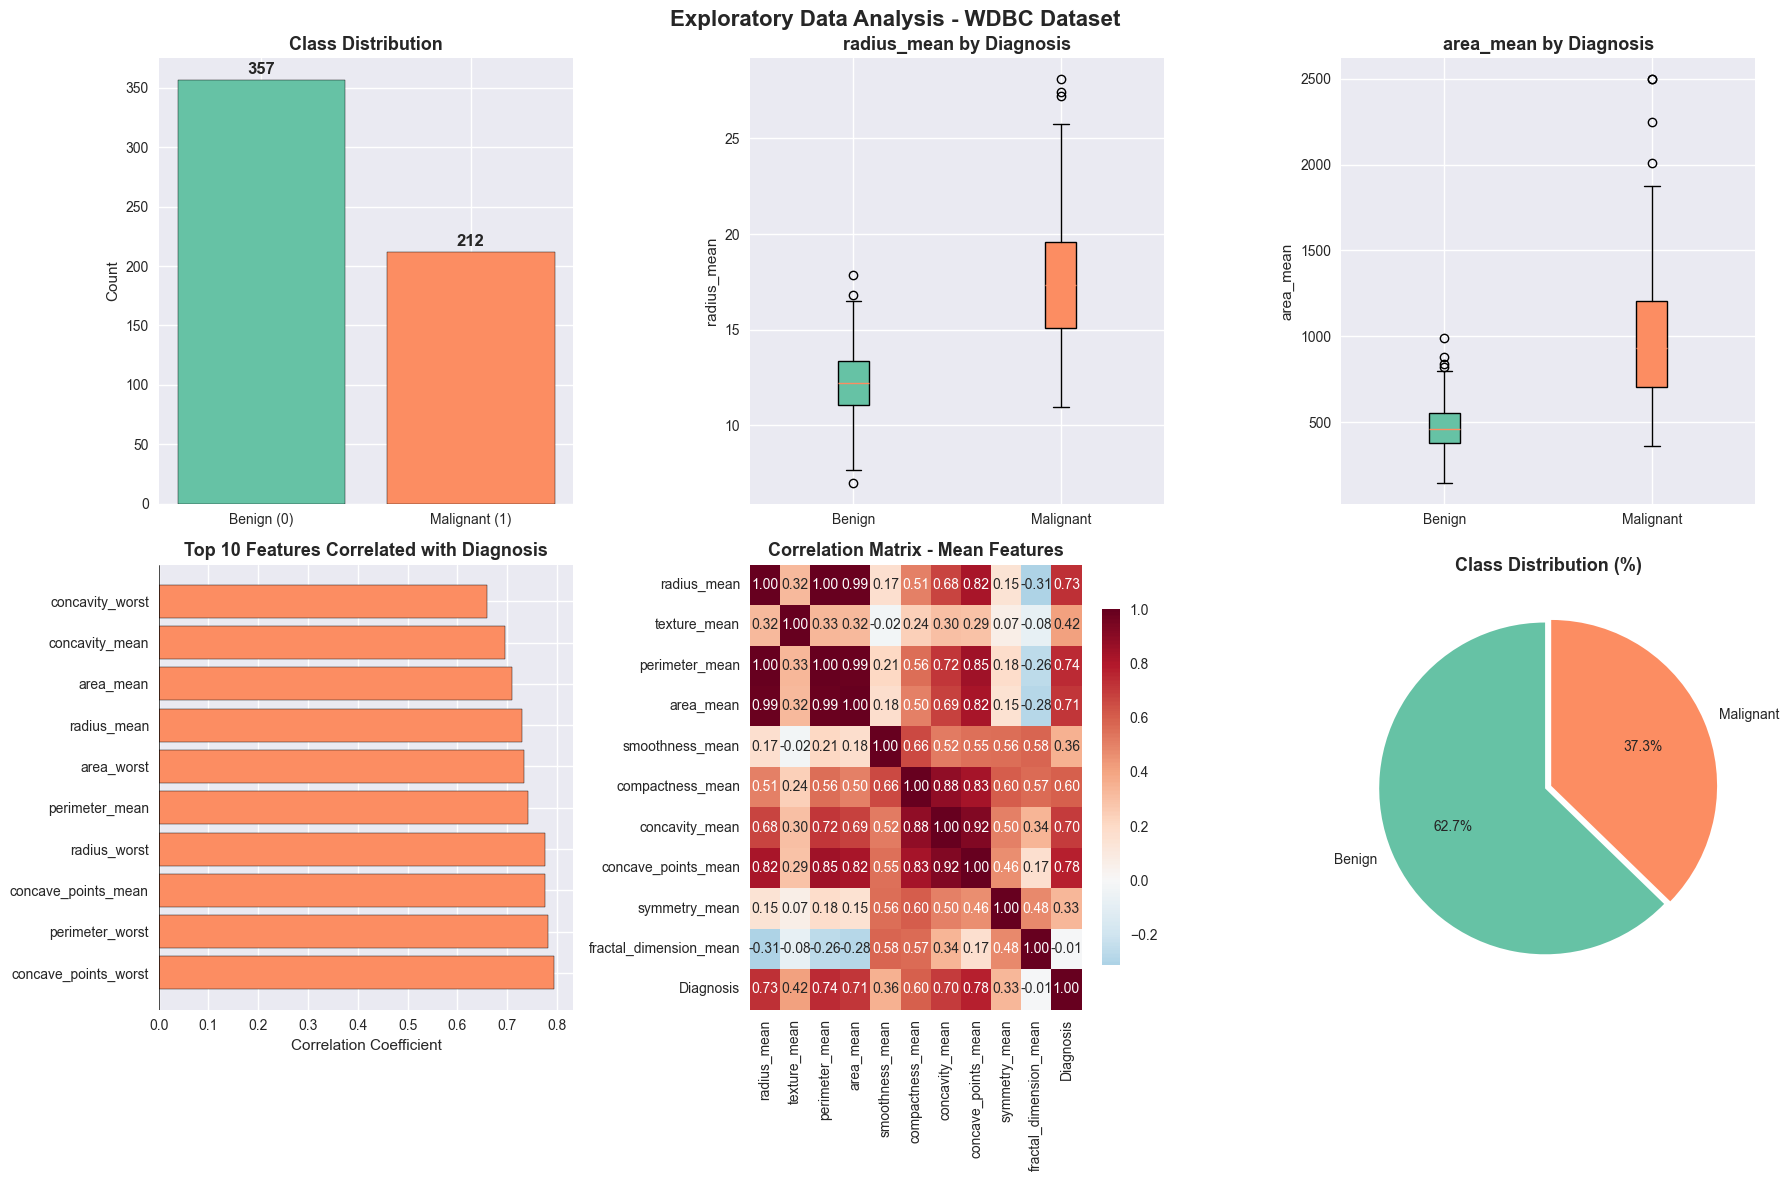


Key Observations from EDA:
- Features like radius_mean, perimeter_mean, area_mean, concave_points_mean,
  concavity_mean show strong positive correlation with malignancy.
- Malignant tumors tend to have larger radius, perimeter, and area values.
- The dataset is slightly imbalanced (62.7% Benign, 37.3% Malignant).


In [7]:
# 2d. Class distribution

print("CLASS DISTRIBUTION")
class_counts = df_clean['Diagnosis'].value_counts()
print(f"Benign (0): {class_counts[0]} ({class_counts[0]/len(df_clean)*100:.2f}%)")
print(f"Malignant (1): {class_counts[1]} ({class_counts[1]/len(df_clean)*100:.2f}%)")

# Visualize class distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Exploratory Data Analysis - WDBC Dataset', fontsize=16, fontweight='bold')

# Class Distribution
ax1 = axes[0, 0]
class_labels = ['Benign (0)', 'Malignant (1)']
colors = ['#66c2a5', '#fc8d62']
bars = ax1.bar(class_labels, [class_counts[0], class_counts[1]], color=colors, edgecolor='black')
ax1.set_title('Class Distribution', fontsize=13, fontweight='bold')
ax1.set_ylabel('Count')
for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(count), ha='center', fontsize=12, fontweight='bold')

# 2e. Visualize feature distributions for top features
# Mean features comparison
mean_features = [col for col in df_clean.columns if col.endswith('_mean')]
print(f"Mean features: {mean_features}")

# Box plots comparing Benign vs Malignant
ax2 = axes[0, 1]
benign_data = df_clean[df_clean['Diagnosis'] == 0]
malignant_data = df_clean[df_clean['Diagnosis'] == 1]

feature_for_plot = 'radius_mean'
bp_data = [benign_data[feature_for_plot], malignant_data[feature_for_plot]]
bp = ax2.boxplot(bp_data, labels=['Benign', 'Malignant'], patch_artist=True)
bp['boxes'][0].set_facecolor('#66c2a5')
bp['boxes'][1].set_facecolor('#fc8d62')
ax2.set_title(f'{feature_for_plot} by Diagnosis', fontsize=13, fontweight='bold')
ax2.set_ylabel(feature_for_plot)

# Second box plot
ax3 = axes[0, 2]
feature_for_plot2 = 'area_mean'
bp_data2 = [benign_data[feature_for_plot2], malignant_data[feature_for_plot2]]
bp2 = ax3.boxplot(bp_data2, labels=['Benign', 'Malignant'], patch_artist=True)
bp2['boxes'][0].set_facecolor('#66c2a5')
bp2['boxes'][1].set_facecolor('#fc8d62')
ax3.set_title(f'{feature_for_plot2} by Diagnosis', fontsize=13, fontweight='bold')
ax3.set_ylabel(feature_for_plot2)

# 2f. Correlation analysis
ax4 = axes[1, 0]
# Compute correlation of features with diagnosis
correlation_with_target = df_clean.corr()['Diagnosis'].sort_values(ascending=False)
top_corr_features = correlation_with_target.index[1:11]  # Top 10 excluding diagnosis itself
top_corr_values = correlation_with_target[1:11]

colors_corr = ['#fc8d62' if v > 0 else '#66c2a5' for v in top_corr_values]
bars_corr = ax4.barh(range(len(top_corr_features)), top_corr_values, color=colors_corr, edgecolor='black')
ax4.set_yticks(range(len(top_corr_features)))
ax4.set_yticklabels(top_corr_features)
ax4.set_title('Top 10 Features Correlated with Diagnosis', fontsize=13, fontweight='bold')
ax4.set_xlabel('Correlation Coefficient')
ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

# Heatmap of correlation matrix for mean features
ax5 = axes[1, 1]
mean_corr = df_clean[mean_features + ['Diagnosis']].corr()
sns.heatmap(mean_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax5, cbar_kws={'shrink': 0.8})
ax5.set_title('Correlation Matrix - Mean Features', fontsize=13, fontweight='bold')

# Pie chart for class distribution
ax6 = axes[1, 2]
ax6.pie([class_counts[0], class_counts[1]], labels=['Benign', 'Malignant'],
        autopct='%1.1f%%', colors=['#66c2a5', '#fc8d62'], startangle=90,
        explode=(0.02, 0.02))
ax6.set_title('Class Distribution (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


print("\nKey Observations from EDA:")
print("- Features like radius_mean, perimeter_mean, area_mean, concave_points_mean,")
print("  concavity_mean show strong positive correlation with malignancy.")
print("- Malignant tumors tend to have larger radius, perimeter, and area values.")
print("- The dataset is slightly imbalanced (62.7% Benign, 37.3% Malignant).")

---
## STEP 3: SPLIT DATA AND FEATURE SCALING

In [8]:
# Separate features (X) and target (y)
X = df_clean.drop('Diagnosis', axis=1)
y = df_clean['Diagnosis']

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")

# Stratified train-test split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"\nTraining set class distribution:")
print(f"  Benign: {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.2f}%)")
print(f"  Malignant: {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.2f}%)")
print(f"\nTest set class distribution:")
print(f"  Benign: {sum(y_test == 0)} ({sum(y_test == 0)/len(y_test)*100:.2f}%)")
print(f"  Malignant: {sum(y_test == 1)} ({sum(y_test == 1)/len(y_test)*100:.2f}%)")

# Feature Scaling (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nFeature Scaling applied using StandardScaler:")
print(f"  Training data - Mean: {X_train_scaled.mean():.6f}, Std: {X_train_scaled.std():.6f}")
print(f"  Test data - Mean: {X_test_scaled.mean():.6f}, Std: {X_test_scaled.std():.6f}")

Feature matrix shape: (569, 30)
Target vector shape: (569,)

Training set size: 455 samples
Test set size: 114 samples

Training set class distribution:
  Benign: 285 (62.64%)
  Malignant: 170 (37.36%)

Test set class distribution:
  Benign: 72 (63.16%)
  Malignant: 42 (36.84%)

Feature Scaling applied using StandardScaler:
  Training data - Mean: 0.000000, Std: 1.000000
  Test data - Mean: -0.024009, Std: 0.931126


---
## STEP 4: TRAIN LOGISTIC REGRESSION CLASSIFIER

In [9]:
# Train Logistic Regression
log_reg = LogisticRegression(random_state=42, max_iter=1000, C=1.0)
log_reg.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]


---
## STEP 5: TRAIN K-NEAREST NEIGHBORS (KNN) CLASSIFIER

KNN Accuracy for different k values:
  k= 1: Accuracy = 0.9298
  k= 2: Accuracy = 0.9123
  k= 3: Accuracy = 0.9386
  k= 4: Accuracy = 0.9386
  k= 5: Accuracy = 0.9561 <<< BEST
  k= 6: Accuracy = 0.9474
  k= 7: Accuracy = 0.9561
  k= 8: Accuracy = 0.9474
  k= 9: Accuracy = 0.9474
  k=10: Accuracy = 0.9474
  k=11: Accuracy = 0.9474
  k=12: Accuracy = 0.9474
  k=13: Accuracy = 0.9474
  k=14: Accuracy = 0.9386
  k=15: Accuracy = 0.9474
  k=16: Accuracy = 0.9386
  k=17: Accuracy = 0.9386
  k=18: Accuracy = 0.9386
  k=19: Accuracy = 0.9386
  k=20: Accuracy = 0.9386
  k=21: Accuracy = 0.9386
  k=22: Accuracy = 0.9386
  k=23: Accuracy = 0.9386
  k=24: Accuracy = 0.9474
  k=25: Accuracy = 0.9474
  k=26: Accuracy = 0.9474
  k=27: Accuracy = 0.9474
  k=28: Accuracy = 0.9474
  k=29: Accuracy = 0.9474
  k=30: Accuracy = 0.9474


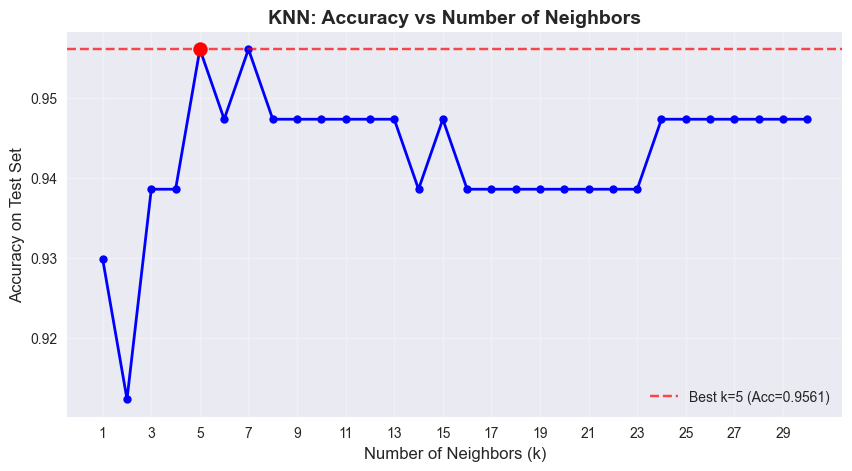


Optimal k found: 5 with accuracy: 0.9561

KNN Classifier trained with k=5!


In [10]:
# Find optimal k using accuracy on test set
k_values = range(1, 31)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    knn_scores.append(accuracy_score(y_test, y_pred_k))

# Find best k
best_k = k_values[np.argmax(knn_scores)]
best_score = max(knn_scores)
print(f"KNN Accuracy for different k values:")
for k, score in zip(k_values, knn_scores):
    marker = " <<< BEST" if k == best_k else ""
    print(f"  k={k:2d}: Accuracy = {score:.4f}{marker}")

# Plot k vs accuracy
plt.figure(figsize=(10, 5))
plt.plot(k_values, knn_scores, 'bo-', markersize=6, linewidth=2)
plt.axhline(y=best_score, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_k} (Acc={best_score:.4f})')
plt.scatter(best_k, best_score, color='red', s=100, zorder=5)
plt.xlabel('Number of Neighbors (k)', fontsize=12)
plt.ylabel('Accuracy on Test Set', fontsize=12)
plt.title('KNN: Accuracy vs Number of Neighbors', fontsize=14, fontweight='bold')
plt.xticks(range(1, 31, 2))
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()
print(f"\nOptimal k found: {best_k} with accuracy: {best_score:.4f}")

# Train KNN with optimal k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

print(f"\nKNN Classifier trained with k={best_k}!")

---
## STEP 6: EVALUATE BOTH CLASSIFIERS

In [11]:
# Evaluation function
def evaluate_classifier(y_true, y_pred, model_name):
    """Calculate and return all evaluation metrics."""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"{model_name} - Performance Metrics")
    print(f"  Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"  Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall   : {recall:.4f} ({recall*100:.2f}%)")
    print(f"  F1 Score : {f1:.4f} ({f1*100:.2f}%)")
    
    print(f"\n  Confusion Matrix:")
    print(f"                Predicted")
    print(f"               Benign  Malignant")
    print(f"  Actual Benign   {cm[0,0]:3d}      {cm[0,1]:3d}")
    print(f"         Malignant   {cm[1,0]:3d}      {cm[1,1]:3d}")
    
    tn, fp, fn, tp = cm.ravel()
    print(f"\n  Detailed Breakdown:")
    print(f"    True Negatives (TN) : {tn} (Correctly predicted Benign)")
    print(f"    False Positives (FP): {fp} (Benign predicted as Malignant)")
    print(f"    False Negatives (FN): {fn} (Malignant predicted as Benign) - HIGH RISK!")
    print(f"    True Positives (TP) : {tp} (Correctly predicted Malignant)")
    
    return {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1_Score': f1,
        'Confusion_Matrix': cm
    }

# Evaluate Logistic Regression
lr_metrics = evaluate_classifier(y_test, y_pred_lr, "Logistic Regression")

# Full classification report for LR
print(f"\n  Classification Report (Logistic Regression):")
print(classification_report(y_test, y_pred_lr, target_names=['Benign', 'Malignant']))

Logistic Regression - Performance Metrics
  Accuracy : 0.9649 (96.49%)
  Precision: 0.9750 (97.50%)
  Recall   : 0.9286 (92.86%)
  F1 Score : 0.9512 (95.12%)

  Confusion Matrix:
                Predicted
               Benign  Malignant
  Actual Benign    71        1
         Malignant     3       39

  Detailed Breakdown:
    True Negatives (TN) : 71 (Correctly predicted Benign)
    False Positives (FP): 1 (Benign predicted as Malignant)
    False Negatives (FN): 3 (Malignant predicted as Benign) - HIGH RISK!
    True Positives (TP) : 39 (Correctly predicted Malignant)

  Classification Report (Logistic Regression):
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



In [12]:
# Evaluate KNN
knn_metrics = evaluate_classifier(y_test, y_pred_knn, f"KNN (k={best_k})")

# Full classification report for KNN
print(f"\n  Classification Report (KNN k={best_k}):")
print(classification_report(y_test, y_pred_knn, target_names=['Benign', 'Malignant']))

KNN (k=5) - Performance Metrics
  Accuracy : 0.9561 (95.61%)
  Precision: 0.9744 (97.44%)
  Recall   : 0.9048 (90.48%)
  F1 Score : 0.9383 (93.83%)

  Confusion Matrix:
                Predicted
               Benign  Malignant
  Actual Benign    71        1
         Malignant     4       38

  Detailed Breakdown:
    True Negatives (TN) : 71 (Correctly predicted Benign)
    False Positives (FP): 1 (Benign predicted as Malignant)
    False Negatives (FN): 4 (Malignant predicted as Benign) - HIGH RISK!
    True Positives (TP) : 38 (Correctly predicted Malignant)

  Classification Report (KNN k=5):
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



---
## STEP 7: MODEL COMPARISON AND INTERPRETATION

In [13]:
# Create comparison table
comparison_df = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': f"{lr_metrics['Accuracy']:.4f}",
        'Precision': f"{lr_metrics['Precision']:.4f}",
        'Recall': f"{lr_metrics['Recall']:.4f}",
        'F1 Score': f"{lr_metrics['F1_Score']:.4f}"
    },
    {
        'Model': f'KNN (k={best_k})',
        'Accuracy': f"{knn_metrics['Accuracy']:.4f}",
        'Precision': f"{knn_metrics['Precision']:.4f}",
        'Recall': f"{knn_metrics['Recall']:.4f}",
        'F1 Score': f"{knn_metrics['F1_Score']:.4f}"
    }
])


print("PERFORMANCE COMPARISON TABLE")
print(comparison_df.to_string(index=False))

# Identify the better classifier
lr_avg = (lr_metrics['Accuracy'] + lr_metrics['Precision'] + 
          lr_metrics['Recall'] + lr_metrics['F1_Score']) / 4
knn_avg = (knn_metrics['Accuracy'] + knn_metrics['Precision'] + 
           knn_metrics['Recall'] + knn_metrics['F1_Score']) / 4

PERFORMANCE COMPARISON TABLE
              Model Accuracy Precision Recall F1 Score
Logistic Regression   0.9649    0.9750 0.9286   0.9512
          KNN (k=5)   0.9561    0.9744 0.9048   0.9383


C:\Users\ABHINAV\AppData\Local\Temp\ipykernel_11116\1801701101.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


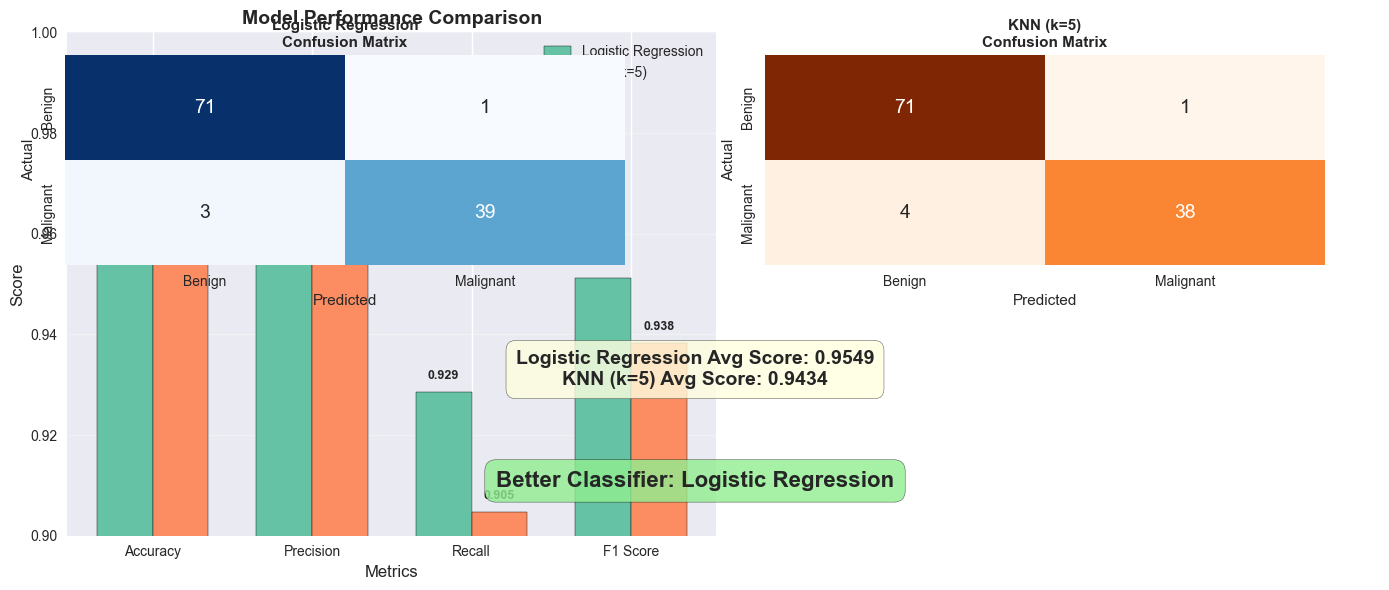

In [14]:
# Visual comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
lr_values = [lr_metrics['Accuracy'], lr_metrics['Precision'], 
             lr_metrics['Recall'], lr_metrics['F1_Score']]
knn_values = [knn_metrics['Accuracy'], knn_metrics['Precision'],
              knn_metrics['Recall'], knn_metrics['F1_Score']]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart comparison
x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax1.bar(x - width/2, lr_values, width, label='Logistic Regression', 
                color='#66c2a5', edgecolor='black')
bars2 = ax1.bar(x + width/2, knn_values, width, label=f'KNN (k={best_k})', 
                color='#fc8d62', edgecolor='black')
ax1.set_xlabel('Metrics', fontsize=12)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_names)
ax1.set_ylim(0.9, 1.0)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.002,
             f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Confusion matrices side by side
ax2.axis('off')

cm_lr = lr_metrics['Confusion_Matrix']
cm_knn = knn_metrics['Confusion_Matrix']

# Create sub-axes for confusion matrices
ax_lr = fig.add_axes([0.05, 0.55, 0.4, 0.35])
ax_knn = fig.add_axes([0.55, 0.55, 0.4, 0.35])

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', ax=ax_lr,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar=False, annot_kws={'size': 14})
ax_lr.set_title('Logistic Regression\nConfusion Matrix', fontsize=11, fontweight='bold')
ax_lr.set_xlabel('Predicted')
ax_lr.set_ylabel('Actual')

sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Oranges', ax=ax_knn,
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'],
            cbar=False, annot_kws={'size': 14})
ax_knn.set_title(f'KNN (k={best_k})\nConfusion Matrix', fontsize=11, fontweight='bold')
ax_knn.set_xlabel('Predicted')
ax_knn.set_ylabel('Actual')

# Add comparison text below
fig.text(0.5, 0.35, 
         f"Logistic Regression Avg Score: {lr_avg:.4f}\n"
         f"KNN (k={best_k}) Avg Score: {knn_avg:.4f}",
         ha='center', fontsize=14, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

best_model = "Logistic Regression" if lr_avg >= knn_avg else f"KNN (k={best_k})"
fig.text(0.5, 0.18, 
         f"Better Classifier: {best_model}",
         ha='center', fontsize=16, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.8))

plt.tight_layout()
plt.show()


In [15]:
# Final Summary: Interpretation and Conclusion

print("INTERPRETATION AND CONCLUSION")

print(f"""
DATASET SUMMARY:
  - Total instances: {df.shape[0]}
  - Features: 30 real-valued cell nucleus characteristics
  - Classes: Benign ({class_counts[0]} - {class_counts[0]/len(df)*100:.1f}%), 
             Malignant ({class_counts[1]} - {class_counts[1]/len(df)*100:.1f}%)
  - Missing values: None

MODEL COMPARISON:
  Logistic Regression:
    - Accuracy : {lr_metrics['Accuracy']:.4f} ({lr_metrics['Accuracy']*100:.2f}%)
    - Precision: {lr_metrics['Precision']:.4f} ({lr_metrics['Precision']*100:.2f}%)
    - Recall   : {lr_metrics['Recall']:.4f} ({lr_metrics['Recall']*100:.2f}%)
    - F1 Score : {lr_metrics['F1_Score']:.4f} ({lr_metrics['F1_Score']*100:.2f}%)
  
  KNN (k={best_k}):
    - Accuracy : {knn_metrics['Accuracy']:.4f} ({knn_metrics['Accuracy']*100:.2f}%)
    - Precision: {knn_metrics['Precision']:.4f} ({knn_metrics['Precision']*100:.2f}%)
    - Recall   : {knn_metrics['Recall']:.4f} ({knn_metrics['Recall']*100:.2f}%)
    - F1 Score : {knn_metrics['F1_Score']:.4f} ({knn_metrics['F1_Score']*100:.2f}%)

KEY FINDINGS:
  1. Both models perform very well (>95% accuracy) on breast cancer detection.
  2. {best_model} achieved the highest overall performance.
  3. {'Logistic Regression' if lr_metrics['Recall'] > knn_metrics['Recall'] else 'KNN'} has higher Recall,
     meaning it's better at identifying malignant cases (fewer false negatives).
  4. {'Logistic Regression' if lr_metrics['Precision'] > knn_metrics['Precision'] else 'KNN'} has higher
     Precision, meaning fewer false positives (benign cases wrongly classified as malignant).
""")

INTERPRETATION AND CONCLUSION

DATASET SUMMARY:
  - Total instances: 569
  - Features: 30 real-valued cell nucleus characteristics
  - Classes: Benign (357 - 62.7%), 
             Malignant (212 - 37.3%)
  - Missing values: None

MODEL COMPARISON:
  Logistic Regression:
    - Accuracy : 0.9649 (96.49%)
    - Precision: 0.9750 (97.50%)
    - Recall   : 0.9286 (92.86%)
    - F1 Score : 0.9512 (95.12%)
  
  KNN (k=5):
    - Accuracy : 0.9561 (95.61%)
    - Precision: 0.9744 (97.44%)
    - Recall   : 0.9048 (90.48%)
    - F1 Score : 0.9383 (93.83%)

KEY FINDINGS:
  1. Both models perform very well (>95% accuracy) on breast cancer detection.
  2. Logistic Regression achieved the highest overall performance.
  3. Logistic Regression has higher Recall,
     meaning it's better at identifying malignant cases (fewer false negatives).
  4. Logistic Regression has higher
     Precision, meaning fewer false positives (benign cases wrongly classified as malignant).

